# Results and loan recommendations

Putting it together: score every farmer, size a loan off their stress capacity, and validate it by backtesting on the real held-out weeks. The headline finding is that **when** a loan is issued matters as much as who it's issued to, because of the seasonality.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.data import load_payments
from src.preprocessing import preprocess
from src.features import build_features
from src.models import HeuristicRiskModel, stress_capacity_table
from src.recommendation import recommend
from src.evaluation import backtest, rolling_backtest, success_by_band
from src.utils import WEEK_COLUMNS

df = preprocess(load_payments())
feats = build_features(df)
model = HeuristicRiskModel().fit(feats)
scores = model.score(feats)
cap = stress_capacity_table(df, WEEK_COLUMNS)
recs = recommend(scores, cap)
recs.head(10)

,risk_score,risk_band,loan_capacity,recommended_loan,decision
farmer_no,,,,,
1158,0.967546,Low,421760.3,168704.0,Approve
1036,0.963440,Low,424944.0,169978.0,Approve
727,0.957727,Low,811402.8,324561.0,Approve
874,0.955760,Low,449810.4,179924.0,Approve
1115,0.952259,Low,274354.6,109742.0,Approve
637,0.951887,Low,402069.2,160828.0,Approve
1054,0.951331,Low,554776.3,221911.0,Approve
1009,0.950112,Low,384111.0,153644.0,Approve
917,0.947962,Low,285460.5,114184.0,Approve


## Who gets approved, and for how much

decision
Approve    685
Reject     590
Name: count, dtype: int64

risk_band
Medium    574
Low       450
High      251
Name: count, dtype: int64


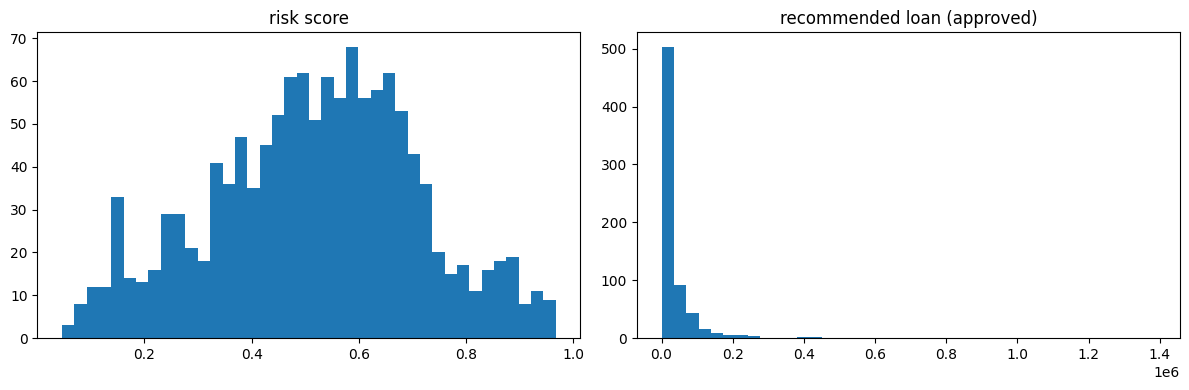

In [3]:
print(recs['decision'].value_counts())
print()
print(recs['risk_band'].value_counts())
approved = recs[recs['decision']=='Approve']
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(recs['risk_score'], bins=40); ax[0].set_title('risk score')
ax[1].hist(approved['recommended_loan'], bins=40); ax[1].set_title('recommended loan (approved)')
plt.tight_layout()

## Backtest: decide on weeks 1-39, test on weeks 40-52
This is the **worst case** - the held-out window is exactly the annual trough, and the first 39 weeks never show how deep it goes.

In [4]:
recs_bt, metrics = backtest(df)
for k, v in metrics.items():
    print(f'{k:26} {v:,.4f}' if isinstance(v, float) else f'{k:26} {v}')

n_farmers                  1275
n_approved                 760
approval_rate              0.5961
repayment_success_rate     0.6487
total_loan_book            39,908,689.0000
total_recovered            30,446,841.0000
recovery_rate              0.7629
expected_loss_rate         0.2371
score_capacity_spearman    0.3825


In [5]:
success_by_band(recs_bt)

,n,repayment_success_rate,avg_loan
risk_band,,,
Low,555,0.581982,68899.209009
Medium,205,0.829268,8144.526829


Even in the worst window, ~65% of loans fully repay and ~76% of the book is recovered. Note the Low band actually loses *more* than Medium here - the safe farmers get bigger loans, and a big loan issued straight into the trough is the riskiest thing in the portfolio.

## Rolling backtest: it's about timing
Repeat the backtest at every possible issue week. Loans issued into a rising season are very safe; only loans issued right before the trough hurt.

,approval_rate,repayment_success_rate,expected_loss_rate,total_loan_book
issue_week,,,,
14,0.620,0.979,0.019,43657111.0
15,0.616,0.976,0.018,44325691.0
16,0.610,0.978,0.015,44760112.0
17,0.609,0.973,0.019,45153062.0
18,0.602,0.975,0.019,45899476.0
19,0.598,0.972,0.012,46347954.0
20,0.596,0.972,0.011,46977376.0
21,0.586,0.972,0.008,47459544.0
22,0.583,0.968,0.014,48443419.0


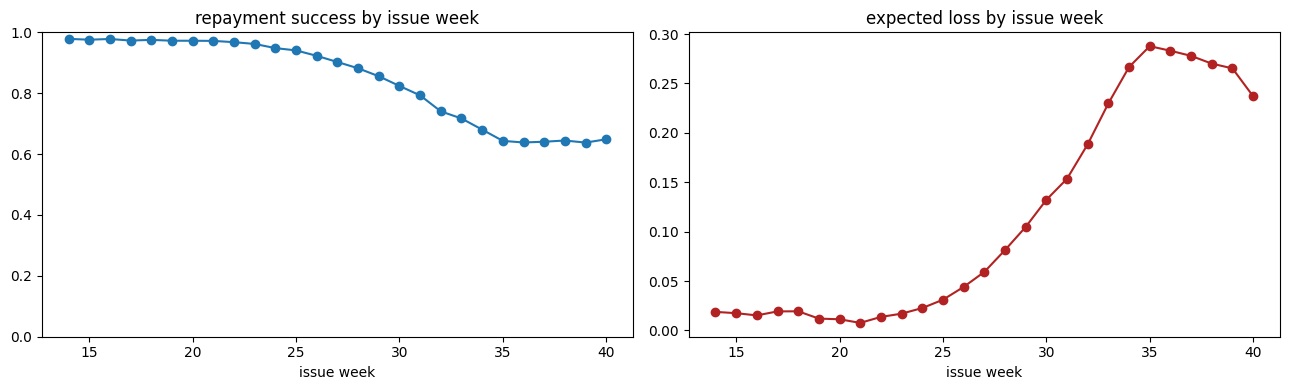

In [6]:
roll = rolling_backtest(df)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(roll.index, roll['repayment_success_rate'], marker='o')
ax[0].set_title('repayment success by issue week'); ax[0].set_xlabel('issue week'); ax[0].set_ylim(0,1)
ax[1].plot(roll.index, roll['expected_loss_rate'], marker='o', color='firebrick')
ax[1].set_title('expected loss by issue week'); ax[1].set_xlabel('issue week')
plt.tight_layout()
roll.round(3)

Loans issued in weeks ~14-26 repay 95-98% with 1-4% loss. The risk is concentrated entirely in loans issued heading into the trough (weeks 30-40). In practice a loan taken at the end of the year runs into weeks 53-65, which is the post-trough recovery - the safe regime - so the deployed case looks like the good end of this chart, not the worst.

## Final recommendation table
The deliverable: risk band and recommended loan per farmer (rejects shown as 0).

In [7]:
out = recs[['risk_score','risk_band','recommended_loan','decision']].copy()
out['risk_score'] = out['risk_score'].round(3)
out.head(15)

,risk_score,risk_band,recommended_loan,decision
farmer_no,,,,
1158,0.968,Low,168704.0,Approve
1036,0.963,Low,169978.0,Approve
727,0.958,Low,324561.0,Approve
874,0.956,Low,179924.0,Approve
1115,0.952,Low,109742.0,Approve
637,0.952,Low,160828.0,Approve
1054,0.951,Low,221911.0,Approve
1009,0.950,Low,153644.0,Approve
917,0.948,Low,114184.0,Approve


## Takeaways

1. **Target** farmers who are active most weeks with a decent worst-quarter floor - that's what the risk score picks up.
2. **Size** loans off the stress capacity (a bad-season assumption), not the yearly average. This is the difference between ~25% and ~2% loss.
3. **Timing** dominates: don't issue a fresh 13-week loan straight into the seasonal trough.

### Future improvements
- A seasonal model that predicts the actual next-13-week level instead of the stress proxy, so good farmers aren't under-lent in good seasons.
- Once real repayment outcomes exist, replace the heuristic score with a supervised model and calibrate the bands.
- Portfolio-level optimisation (diversify issue timing) rather than scoring farmers one at a time.